# Ein Durchgängiges Beispiel

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Daten importieren und darstellen

Daten importieren mit `numpy.loadtxt()` und darstellen mit `matplotlib.pyplot.plot()`:

In [2]:
data = np.loadtxt("weight.csv", delimiter=";", skiprows=1, usecols=(1, 2))
data[:5]

array([[ 0. , 74.3],
       [ 3. , 74.3],
       [ 4. , 74.3],
       [ 5. , 73.5],
       [ 6. , 73.3]])

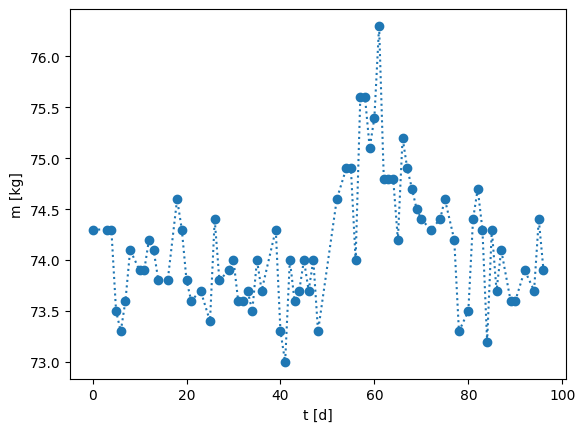

In [3]:
t, m = data.T

plt.plot(t, m, "o:")
plt.xlabel("t [d]")
plt.ylabel("m [kg]")
plt.show()

## Interpolation

Daten können mit [`scipy.interpolate.make_interp_spline`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.make_interp_spline.html) linear, quadratisch oder kubisch interpoliert werden, siehe [1-D Interpolation (SciPy Manual)](https://docs.scipy.org/doc/scipy/tutorial/interpolate/1D.html).

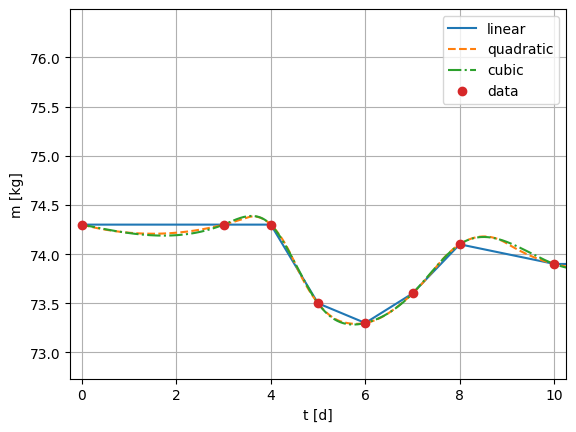

In [4]:
from scipy.interpolate import make_interp_spline

# Interpolationsfunktionen
f_linear = make_interp_spline(t, m, k=1)
f_quadratic = make_interp_spline(t, m, k=2)
f_cubic = make_interp_spline(t, m, k=3, bc_type="natural")

# Interpolationswerte
n = int(t.max() - t.min()) * 100 + 1
t_interp = np.linspace(t.min(), t.max(), n)
m_linear = f_linear(t_interp)
m_quadratic = f_quadratic(t_interp)
m_cubic = f_cubic(t_interp)

plt.plot(t_interp, m_linear, "-", label="linear")
plt.plot(t_interp, m_quadratic, "--", label="quadratic")
plt.plot(t_interp, m_cubic, "-.", label="cubic")
plt.plot(t, m, "o", label="data")
plt.xlim(-0.25, 10.25)
plt.xlabel("t [d]")
plt.ylabel("m [kg]")
plt.legend()
plt.grid()
plt.show()

## Nullstellen bestimmen / Gleichungen lösen

Wann sind 76 kg erreicht?

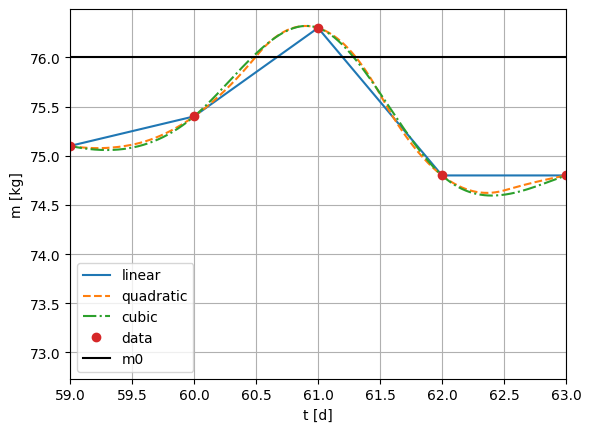

In [5]:
m0 = 76
m0_array = np.full_like(t, m0)

plt.plot(t_interp, m_linear, "-", label="linear")
plt.plot(t_interp, m_quadratic, "--", label="quadratic")
plt.plot(t_interp, m_cubic, "-.", label="cubic")
plt.plot(t, m, "o", label="data")
plt.plot(t, m0_array, "k", label="m0")
plt.xlim(59, 63)
plt.xlabel("t [d]")
plt.ylabel("m [kg]")
plt.legend()
plt.grid()
plt.show()

Wir interpolieren $m(t)-m_0$ und berechnen die Nullstellen davon.

In [6]:
from scipy.optimize import bisect

a, b = 60, 61
# a, b = 61, 62
for i, method in enumerate(["linear", "quadratic", "cubic"]):
    f = make_interp_spline(t, m - m0, k=i + 1)
    t0 = bisect(f, a, b)
    print(method)
    print(f"t0 = {t0},\t f0 = {f(t0)}\n")

linear
t0 = 60.66666666666606,	 f0 = -5.457023721788801e-13

quadratic
t0 = 60.49306609025916,	 f0 = -5.91859894427671e-13

cubic
t0 = 60.467816586946356,	 f0 = 2.1724670673517466e-12



## Ableitung

Für die numerische Ableitung können wir `numpy.gradient()`verwenden.

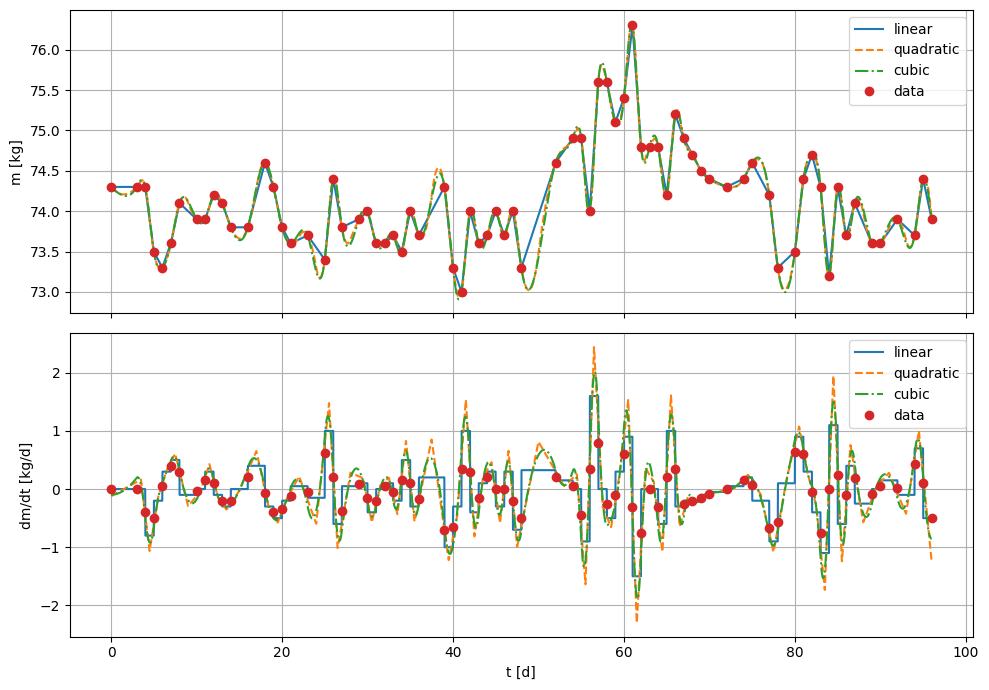

In [7]:
dmdt = np.gradient(m, t)
dmdt_linear = np.gradient(m_linear, t_interp)
dmdt_quadratic = np.gradient(m_quadratic, t_interp)
dmdt_cubic = np.gradient(m_cubic, t_interp)

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
ax0.plot(t_interp, m_linear, "-", label="linear")
ax0.plot(t_interp, m_quadratic, "--", label="quadratic")
ax0.plot(t_interp, m_cubic, "-.", label="cubic")
ax0.plot(t, m, "o", label="data")
ax0.set_ylabel("m [kg]")
ax0.legend()
ax0.grid()
ax1.plot(t_interp, dmdt_linear, "-", label="linear")
ax1.plot(t_interp, dmdt_quadratic, "--", label="quadratic")
ax1.plot(t_interp, dmdt_cubic, "-.", label="cubic")
ax1.plot(t, dmdt, "o", label="data")
ax1.set_xlabel("t [d]")
ax1.set_ylabel("dm/dt [kg/d]")
ax1.legend()
ax1.grid()
plt.tight_layout()
plt.show()

Zoom in einen stark schwankenden Bereich.

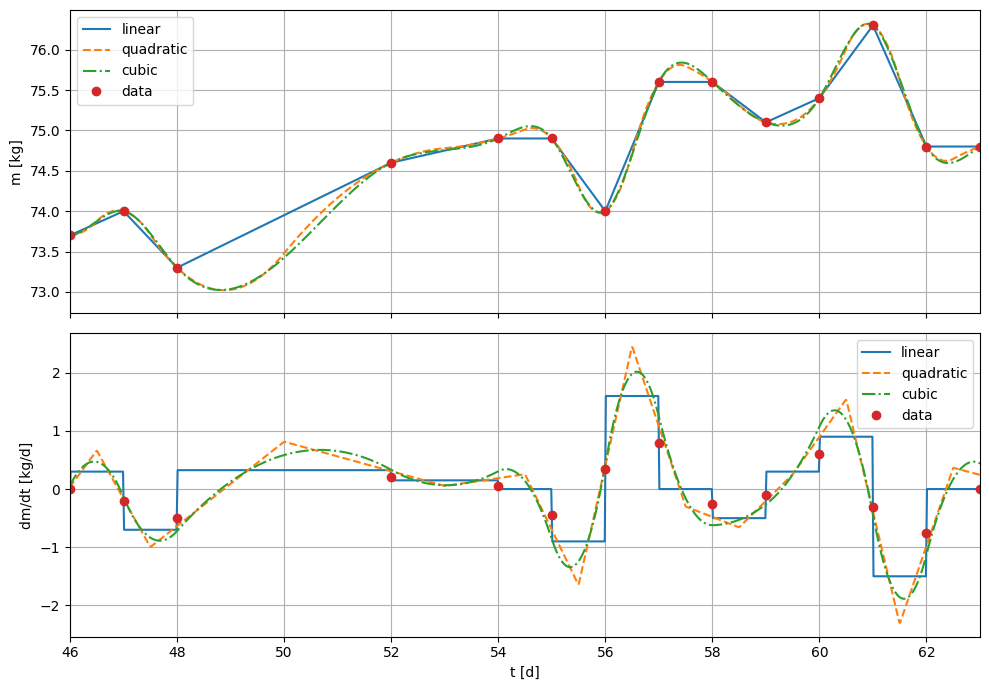

In [8]:
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
ax0.plot(t_interp, m_linear, "-", label="linear")
ax0.plot(t_interp, m_quadratic, "--", label="quadratic")
ax0.plot(t_interp, m_cubic, "-.", label="cubic")
ax0.plot(t, m, "o", label="data")
ax0.set_xlim(46, 63)
ax0.set_ylabel("m [kg]")
ax0.legend()
ax0.grid()
ax1.plot(t_interp, dmdt_linear, "-", label="linear")
ax1.plot(t_interp, dmdt_quadratic, "--", label="quadratic")
ax1.plot(t_interp, dmdt_cubic, "-.", label="cubic")
ax1.plot(t, dmdt, "o", label="data")
ax1.set_xlabel("t [d]")
ax1.set_ylabel("dm/dt [kg/d]")
ax1.legend()
ax1.grid()
plt.tight_layout()
plt.show()

- Die lineare Interpolation ist an den Stützstellen nicht differenzierbar.
- Die Ableitung der quadratischen Interpolation hat Knicks zwischen den Stützstellen und ist daher nur einmal differenzierbar.
- Die kubische Interpolation ist zweimal differenzierbar, kann aber an den Rändern ggf. zu starken Schwankungen führen.

## Integration

Für die Integration von Funktionen können wir `scipy.integrate.quad()` verwenden und für die Integration von Daten `scipy.integrate.trapezoid()`, siehe [Integration (SciPy Manual)](https://docs.scipy.org/doc/scipy/tutorial/integrate.html).

### Mittelwert der Daten

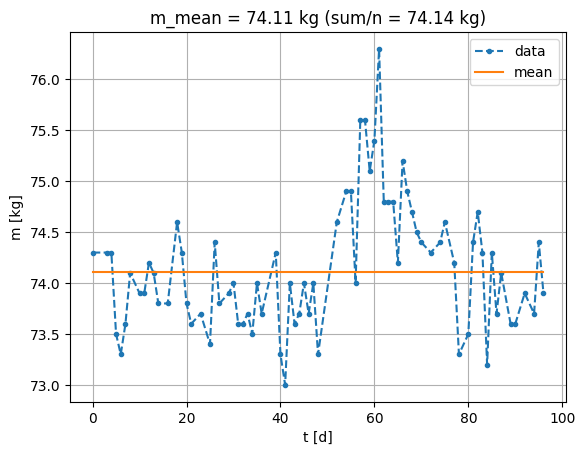

In [9]:
# integriere über m
from scipy.integrate import trapezoid

t_span = t.max() - t.min()
m_mean = trapezoid(m, t) / t_span

plt.plot(t, m, ".--", label="data")
plt.plot(t, np.full_like(t, m_mean), "-", label="mean")
plt.xlabel("t [d]")
plt.ylabel("m [kg]")
plt.legend()
plt.grid()
plt.title(f"m_mean = {m_mean:.2f} kg (sum/n = {m.sum()/len(m):.2f} kg)")
plt.show()

### Mittelwert der Interpolationsfunktion

In [10]:
# integriere über m
from scipy.integrate import quad

print("linear: ", quad(f_linear, t.min(), t.max(), limit=1000) / t_span)
print("quadratic: ", quad(f_quadratic, t.min(), t.max(), limit=1000) / t_span)
print("cubic: ", quad(f_cubic, t.min(), t.max(), limit=1000) / t_span)

linear:  [7.41088542e+01 2.55795385e-13]
quadratic:  [7.40939637e+01 1.10052370e-06]
cubic:  [7.40908585e+01 1.06193118e-06]


### Glättung mithilfe der Faltung

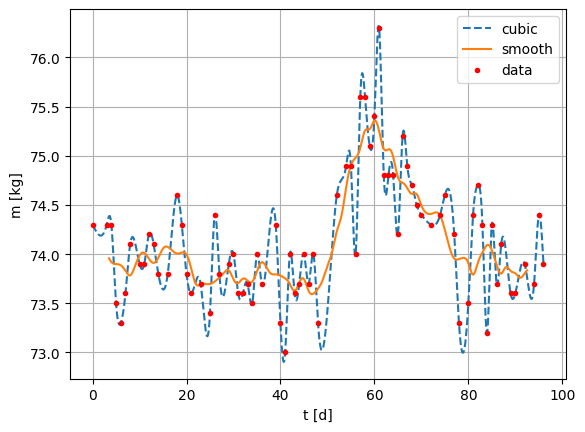

In [11]:
width = 7
half_width = width / 2


def tophat(t):
    filter = (-half_width <= t) & (t <= half_width)
    return np.where(filter, 1.0 / width, 0.0)


@np.vectorize
def m_smooth(t):
    return quad(
        lambda tau: tophat(tau) * f_cubic(t - tau),
        -half_width,
        half_width,
        limit=1000,
    )[0]


t_smooth = np.linspace(t.min() + half_width, t.max() - half_width, 500)
m_smooth_array = m_smooth(t_smooth)

plt.plot(t_interp, m_cubic, "--", label="cubic")
plt.plot(t_smooth, m_smooth_array, "-", label="smooth")
plt.plot(t, m, "r.", label="data")
# plt.xlim(half_width, t.max() - half_width)
plt.xlabel("t [d]")
plt.ylabel("m [kg]")
plt.legend()
plt.grid()
plt.show()

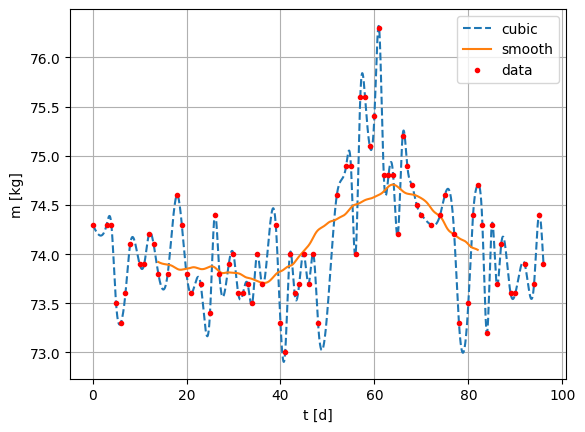

In [12]:
width = 28
half_width = width / 2


def tophat(t):
    filter = (-half_width <= t) & (t <= half_width)
    return np.where(filter, 1.0 / width, 0.0)


@np.vectorize
def m_smooth(t):
    return quad(
        lambda tau: tophat(tau) * f_cubic(t - tau), -half_width, half_width, limit=1000
    )[0]


t_smooth = np.linspace(t.min() + half_width, t.max() - half_width, 500)
m_smooth_array = m_smooth(t_smooth)

plt.plot(t_interp, m_cubic, "--", label="cubic")
plt.plot(t_smooth, m_smooth_array, "-", label="smooth")
plt.plot(t, m, "r.", label="data")
plt.xlabel("t [d]")
plt.ylabel("m [kg]")
plt.legend()
plt.grid()
plt.show()